#### Imports

In [51]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping
import optuna
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### Starting Connection and Querying Data from Supabase

In [52]:
# Load environment variables from .env
load_dotenv()

# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)
# If using Transaction Pooler or Session Pooler, we want to ensure we disable SQLAlchemy client side pooling -
# https://docs.sqlalchemy.org/en/20/core/pooling.html#switching-pool-implementations
# engine = create_engine(DATABASE_URL, poolclass=NullPool)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [53]:
query = """
SELECT *
FROM "RBPointProjection"
WHERE season BETWEEN 2018 AND 2024
"""

rb_df = pd.read_sql(query, engine)

print(rb_df.shape)
rb_df.head()

(10297, 67)


,player_id,player_name,team,season,week,opponent_team,fantasy_points_ppr,carries_prev,rushing_yards_prev,rushing_tds_prev,...,rb_targets_allowed_roll3_mean,rb_targets_allowed_roll5_mean,rb_receptions_allowed_roll3_mean,rb_receptions_allowed_roll5_mean,rb_rec_yards_allowed_roll3_mean,rb_rec_yards_allowed_roll5_mean,rb_rec_tds_allowed_roll3_mean,rb_rec_tds_allowed_roll5_mean,rb_fp_allowed_roll3_mean,rb_fp_allowed_roll5_mean
0,00-0023500,F.Gore,MIA,2018,1,TEN,6.1,261.0,961.0,3.0,...,6.000000,6.75,5.000000,5.50,35.500000,60.75,0.0,0.50,17.35,23.050
1,00-0023500,F.Gore,MIA,2018,2,NYJ,5.4,261.0,961.0,3.0,...,7.000000,8.50,5.500000,7.25,41.000000,63.25,0.0,0.25,18.80,27.375
2,00-0032104,A.Abdullah,MIN,2021,1,CIN,3.9,NaN,NaN,NaN,...,4.500000,4.75,4.000000,4.00,27.500000,35.50,0.5,0.50,26.80,23.150
3,00-0023500,F.Gore,MIA,2018,3,LV,1.2,261.0,961.0,3.0,...,4.500000,5.00,3.000000,3.75,30.500000,28.00,0.5,0.50,25.30,22.475
4,00-0023500,F.Gore,MIA,2018,4,NE,13.7,261.0,961.0,3.0,...,7.666667,8.00,5.666667,6.00,51.333333,58.00,0.0,0.00,24.60,26.225


In [54]:
rb_df['atleast10'] = rb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 10.0 else 0)
rb_df['atleast15'] = rb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 15.0 else 0)
rb_df['atleast20'] = rb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 20.0 else 0)

#### 10 Point Probability Model

#### Building Feature and Target Set

In [55]:
TARGET = "atleast10"

keys_df = rb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast20", "atleast15", 'fantasy_points_ppr', TARGET]
X = rb_df.drop(columns=[c for c in drop_cols if c in rb_df.columns]).copy()
y = rb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (10297, 59) y shape: (10297,)


#### Building Training, Validation, and Testing Set

In [56]:
train_mask = rb_df["season"].between(2018, 2022)
val_mask   = rb_df["season"].eq(2023)
test_mask  = rb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)

print(X_train.shape, X_val.shape, X_test.shape)

(7273, 59) (1501, 59) (1523, 59)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [58]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 2564, number of negative: 4709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4871
[LightGBM] [Info] Number of data points in the train set: 7273, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.352537 -> initscore=-0.607907
[LightGBM] [Info] Start training from score -0.607907
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [59]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [60]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.7741505662891406
Precision: 0.6666666666666666
Recall: 0.5962732919254659
F1 Score: 0.6295081967213115
ROC-AUC: 0.818231461030641


Test Metrics
Accuracy: 0.7957977675640184
Precision: 0.7199124726477024
Recall: 0.642578125
F1 Score: 0.6790505675954592
ROC-AUC: 0.8381919974035608


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

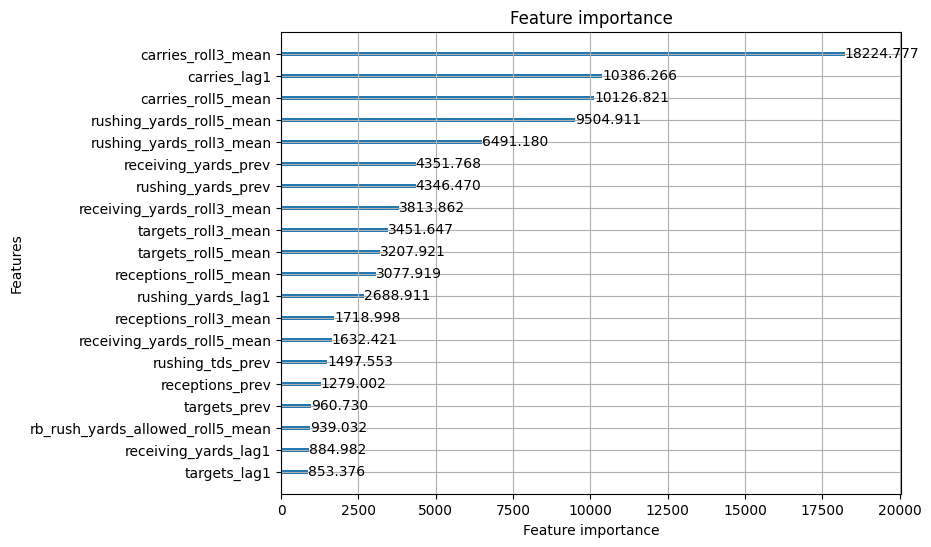

In [61]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [62]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast10"] = val_proba
val_preds_df["pred_atleast10"] = val_pred
val_preds_df["true_atleast10"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast10,pred_atleast10,true_atleast10
0,00-0029239,B.Bolden,2023,1,LV,DEN,0.200955,0,0
1,00-0029239,B.Bolden,2023,14,LV,MIN,0.058199,0,0
2,00-0029239,B.Bolden,2023,15,LV,LAC,0.057853,0,0
3,00-0029239,B.Bolden,2023,16,LV,KC,0.101001,0,0
4,00-0029239,B.Bolden,2023,17,LV,IND,0.080554,0,0
5,00-0030513,L.Murray,2023,1,BUF,NYJ,0.366446,0,0
6,00-0030513,L.Murray,2023,2,BUF,LV,0.206128,0,1
7,00-0030513,L.Murray,2023,3,BUF,WAS,0.285990,0,0
8,00-0030513,L.Murray,2023,4,BUF,MIA,0.233711,0,0
9,00-0030513,L.Murray,2023,5,BUF,JAX,0.219897,0,0


#### 15 Point Probability Model

#### Building Feature and Target Set

In [63]:
TARGET = "atleast15"

keys_df = rb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast20", 'fantasy_points_ppr', TARGET]
X = rb_df.drop(columns=[c for c in drop_cols if c in rb_df.columns]).copy()
y = rb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (10297, 59) y shape: (10297,)


#### Building Training, Validation, and Testing Set

In [64]:
train_mask = rb_df["season"].between(2018, 2022)
val_mask   = rb_df["season"].eq(2023)
test_mask  = rb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [66]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 1473, number of negative: 5800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4871
[LightGBM] [Info] Number of data points in the train set: 7273, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202530 -> initscore=-1.370557
[LightGBM] [Info] Start training from score -1.370557
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [67]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [68]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.8301132578281146
Precision: 0.5543478260869565
Recall: 0.19245283018867926
F1 Score: 0.2857142857142857
ROC-AUC: 0.8245511998534532


Test Metrics
Accuracy: 0.8122127380170716
Precision: 0.55
Recall: 0.1858108108108108
F1 Score: 0.2777777777777778
ROC-AUC: 0.8286016762483754


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

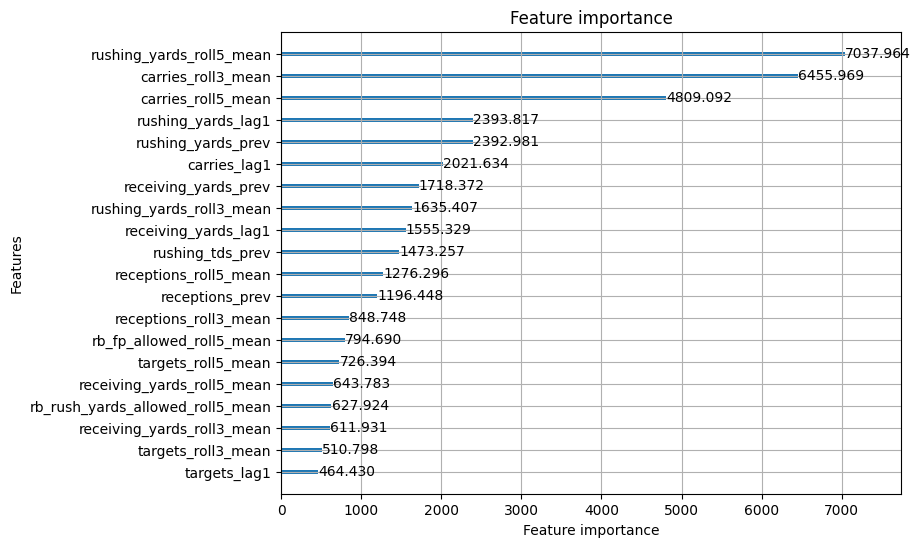

In [69]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [70]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast15"] = val_proba
val_preds_df["pred_atleast15"] = val_pred
val_preds_df["true_atleast15"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast15,pred_atleast15,true_atleast15
0,00-0029239,B.Bolden,2023,1,LV,DEN,0.102051,0,0
1,00-0029239,B.Bolden,2023,14,LV,MIN,0.026049,0,0
2,00-0029239,B.Bolden,2023,15,LV,LAC,0.020797,0,0
3,00-0029239,B.Bolden,2023,16,LV,KC,0.037861,0,0
4,00-0029239,B.Bolden,2023,17,LV,IND,0.029672,0,0
5,00-0030513,L.Murray,2023,1,BUF,NYJ,0.163786,0,0
6,00-0030513,L.Murray,2023,2,BUF,LV,0.078793,0,0
7,00-0030513,L.Murray,2023,3,BUF,WAS,0.109663,0,0
8,00-0030513,L.Murray,2023,4,BUF,MIA,0.107659,0,0
9,00-0030513,L.Murray,2023,5,BUF,JAX,0.125312,0,0


#### 20 Point Probability

#### Building Feature and Target Set

In [71]:
TARGET = "atleast20"

keys_df = rb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast15", 'fantasy_points_ppr', TARGET]
X = rb_df.drop(columns=[c for c in drop_cols if c in rb_df.columns]).copy()
y = rb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (10297, 59) y shape: (10297,)


#### Building Training, Validation, and Testing Set

In [72]:
train_mask = rb_df["season"].between(2018, 2022)
val_mask   = rb_df["season"].eq(2023)
test_mask  = rb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [74]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 758, number of negative: 6515
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4871
[LightGBM] [Info] Number of data points in the train set: 7273, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.104221 -> initscore=-2.151179
[LightGBM] [Info] Start training from score -2.151179
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [75]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.3
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [76]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.8974017321785477
Precision: 0.4126984126984127
Recall: 0.18181818181818182
F1 Score: 0.2524271844660194
ROC-AUC: 0.8138897185288938


Test Metrics
Accuracy: 0.8824688115561392
Precision: 0.2727272727272727
Recall: 0.14583333333333334
F1 Score: 0.19004524886877827
ROC-AUC: 0.8166344371928128


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

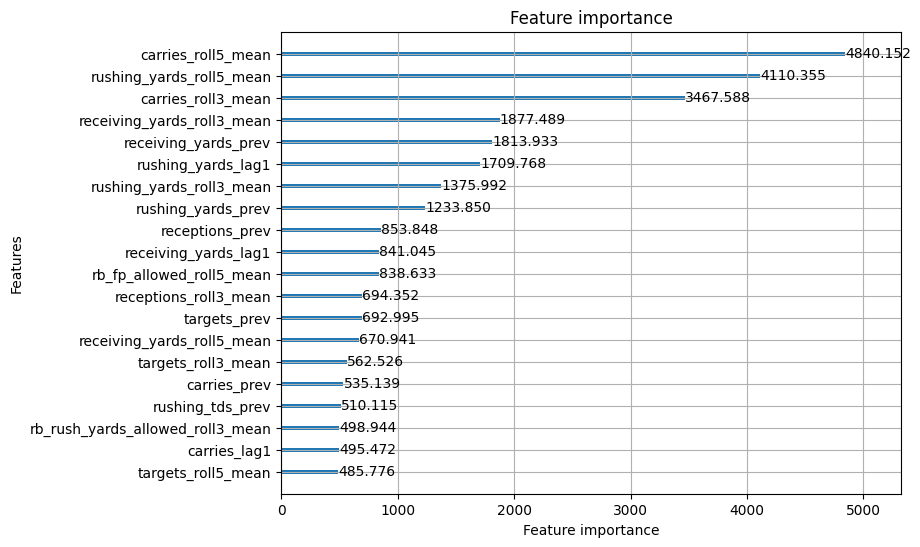

In [77]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [78]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast20"] = val_proba
val_preds_df["pred_atleast20"] = val_pred
val_preds_df["true_atleast20"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast20,pred_atleast20,true_atleast20
0,00-0029239,B.Bolden,2023,1,LV,DEN,0.034316,0,0
1,00-0029239,B.Bolden,2023,14,LV,MIN,0.013031,0,0
2,00-0029239,B.Bolden,2023,15,LV,LAC,0.011009,0,0
3,00-0029239,B.Bolden,2023,16,LV,KC,0.010764,0,0
4,00-0029239,B.Bolden,2023,17,LV,IND,0.011297,0,0
5,00-0030513,L.Murray,2023,1,BUF,NYJ,0.068594,0,0
6,00-0030513,L.Murray,2023,2,BUF,LV,0.021141,0,0
7,00-0030513,L.Murray,2023,3,BUF,WAS,0.022644,0,0
8,00-0030513,L.Murray,2023,4,BUF,MIA,0.029793,0,0
9,00-0030513,L.Murray,2023,5,BUF,JAX,0.042468,0,0
